# Generator-Critic - LangGraph Implementation

> "The model critiques; the harness decides."

This notebook implements Generator-Critic as a **LangGraph `StateGraph`**: generate an artifact, critique it, run a deterministic policy gate, and optionally draft a revision. The [LangChain version](../langchain/tutorial.ipynb) uses LCEL pipes for the same data and policy.

## What this pattern does

Generator-Critic separates three jobs that often get blurred together:

1. **Generate** the artifact under review.
2. **Critique** the artifact as evidence: score, issues, blockers, warnings.
3. **Gate** the artifact in deterministic code.

| | `langgraph/` (StateGraph) | `langchain/` (LCEL) |
|---|---|---|
| **Mechanism** | Explicit nodes: `generate -> critique -> gate -> revise` | `prompt | model | parser`, then a runnable gate |
| **Visibility** | Every transition is visible in the graph | Shorter pipe, less explicit routing |
| **Shared pieces** | `shared.py` parser, policy, mock JSON, reviser | Same `shared.py` pieces |
| **Boundary** | Revision draft ends the pass; no auto-accept | Same: revision draft still needs a fresh critique |

## Setup

The mock runs are deterministic and need no API key. The real-backend cell at the end uses the root `.env` through [`model_config.py`](../../../model_config.py) and only calls a live model when `run_real_llm` is true.

In [1]:
from __future__ import annotations

# ruff: noqa: E402

import sys
from pathlib import Path
from typing import Callable, TypedDict

# Notebooks may run from the repo root, this folder, nbmake, or nbconvert.
# Add the directory that owns each marker file so root helpers and local shared
# pattern files resolve without installing the repository as a package.
for _marker in ("shared.py", "model_config.py", "nbtools.py"):
    _dir = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / _marker).exists())
    sys.path.insert(0, str(_dir))

from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import END, START, StateGraph

from model_config import get_model, run_real_llm_enabled
from nbtools import show_graph
from pattern import Artifact, ChainResult, Critique, Decision
from shared import (
    BAD_CRITIQUE_JSON,
    CRITIC_SYSTEM_PROMPT,
    DEFAULT_PROMPT,
    GOOD_CRITIQUE_JSON,
    NEEDS_REVISION_CRITIQUE_JSON,
    default_policy,
    parse_critique_json,
    print_trace,
    revise_with_evidence,
    scripted_critic,
    scripted_generator,
)


## State

The state is intentionally small: the prompt, the artifact, the critique, the policy decision, and an audit trace. The graph shows the chain boundary explicitly: a revision can be drafted, but it is not accepted in the same pass.

In [2]:
class ReviewState(TypedDict, total=False):
    prompt: str
    artifact: Artifact
    critique: Critique
    decision: Decision
    trace: list[str]


GeneratorFn = Callable[[str], Artifact]
CriticFn = Callable[[Artifact], Critique]
ReviserFn = Callable[[Artifact, Critique], Artifact]

## Core nodes

Each node owns one role. The gate node is the important one: it uses `AcceptancePolicy` from the core pattern, not the critic's prose, to decide whether the artifact can pass.

In [3]:
def build_graph(
    generator: GeneratorFn,
    critic: CriticFn,
    reviser: ReviserFn | None = None,
    *,
    policy=None,
):
    policy = policy or default_policy()

    def generate_node(state: ReviewState) -> dict:
        artifact = generator(state["prompt"])
        return {"artifact": artifact, "trace": ["generated"]}

    def critique_node(state: ReviewState) -> dict:
        critique = critic(state["artifact"])
        return {"critique": critique, "trace": state.get("trace", []) + ["critiqued"]}

    def gate_node(state: ReviewState) -> dict:
        # The critic provides evidence; AcceptancePolicy owns the decision.
        decision = policy.decide(state["critique"])
        return {"decision": decision, "trace": state.get("trace", []) + [decision.value]}

    def revise_node(state: ReviewState) -> dict:
        if reviser is None:
            return {}
        # Revision is a draft artifact only. The graph ends here so the revised
        # text cannot be accepted without a separate generate/critique/gate pass.
        artifact = reviser(state["artifact"], state["critique"])
        return {"artifact": artifact, "trace": state.get("trace", []) + ["revision_drafted"]}

    def route_after_gate(state: ReviewState) -> str:
        if state["decision"] is Decision.NEEDS_REVISION and reviser is not None:
            return "revise"
        return "done"

    builder = StateGraph(ReviewState)
    builder.add_node("generate", generate_node)
    builder.add_node("critique", critique_node)
    builder.add_node("gate", gate_node)
    builder.add_node("revise", revise_node)
    builder.add_edge(START, "generate")
    builder.add_edge("generate", "critique")
    builder.add_edge("critique", "gate")
    builder.add_conditional_edges("gate", route_after_gate, {"revise": "revise", "done": END})
    builder.add_edge("revise", END)
    return builder.compile()


def result_from_state(state: ReviewState) -> ChainResult:
    return ChainResult(
        decision=state["decision"],
        artifact=state["artifact"],
        critique=state["critique"],
        trace=state["trace"],
    )


## Assemble the demo graph

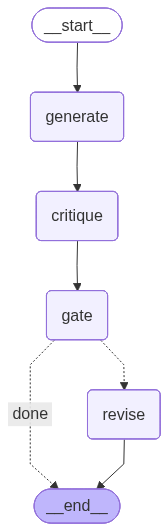

In [4]:
# LangGraph does not need a LangChain fake chat model here. The graph accepts
# ordinary Python callables, so scripted_generator and scripted_critic are the
# framework-agnostic fake roles equivalent to PR #2's fake LLM adapter.
accepted_graph = build_graph(
    scripted_generator,
    scripted_critic(GOOD_CRITIQUE_JSON),
    reviser=revise_with_evidence,
)
show_graph(accepted_graph, alt="Generator-Critic LangGraph")


## Mock run 1: clean critique accepts

In [5]:
state = accepted_graph.invoke({"prompt": DEFAULT_PROMPT})
print_trace(result_from_state(state))

decision: accepted
trace: generated -> critiqued -> accepted
score: 0.9
issues: none
artifact: We identified elevated checkout errors. Impact is limited to card payments. Next update in 30 minutes.


## Mock run 2: blocker drafts a revision, but does not auto-accept

In [6]:
# Same generated draft, different critic evidence. The conditional edge follows
# the policy decision into revise, then ends the pass without auto-accepting.
revision_graph = build_graph(
    scripted_generator,
    scripted_critic(NEEDS_REVISION_CRITIQUE_JSON),
    reviser=revise_with_evidence,
)
state = revision_graph.invoke({"prompt": DEFAULT_PROMPT})
print_trace(result_from_state(state))


decision: needs_revision
trace: generated -> critiqued -> needs_revision -> revision_drafted
score: 0.74
issues: ['blocker:sentence 2:impact claim lacks a cited source']
artifact: We identified elevated checkout errors. Impact is limited to card payments. Next update in 30 minutes. Evidence: status dashboard incident INC-42.


## Mock run 3: malformed critic output fails closed

In [7]:
# The malformed critic response exercises the shared fail-closed parser. The
# graph sees a blocker Critique, not raw invalid JSON.
parse_failure_graph = build_graph(
    scripted_generator,
    scripted_critic(BAD_CRITIQUE_JSON),
    reviser=revise_with_evidence,
)
state = parse_failure_graph.invoke({"prompt": DEFAULT_PROMPT})
print_trace(result_from_state(state))


decision: needs_revision
trace: generated -> critiqued -> needs_revision -> revision_drafted
score: 0.0
issues: ['blocker:critic:critic output could not be parsed: JSONDecodeError: Expecting property name enclosed in double quotes: line 1 column 2 (char 1)']
artifact: We identified elevated checkout errors. Impact is limited to card payments. Next update in 30 minutes. Evidence: status dashboard incident INC-42.


## Real backend

The same graph can use a live model. Live calls are opt-in through `RUN_REAL_LLM=1` (or local lowercase `run_real_llm=1`) so a normal **Run All** stays deterministic and does not spend API credits.

In [8]:
# Keep the opt-in as a visible notebook variable. If this prints False, the
# real call is intentionally disabled before get_model() can touch the backend.
run_real_llm = run_real_llm_enabled()
model = get_model() if run_real_llm else None

if not run_real_llm:
    print("Skipping real backend run; set RUN_REAL_LLM=1 (or run_real_llm=1) and configure .env to enable it.")
elif model is None:
    print("Skipping real backend run; RUN_REAL_LLM is enabled but no configured model could be loaded.")
else:
    def real_generator(prompt: str) -> Artifact:
        response = model.invoke([
            SystemMessage(content="Draft a concise customer-facing incident update."),
            HumanMessage(content=prompt),
        ])
        return Artifact(content=str(response.content), metadata={"source": "real_model"})

    def real_critic(artifact: Artifact) -> Critique:
        response = model.invoke([
            SystemMessage(content=(
                CRITIC_SYSTEM_PROMPT
            )),
            HumanMessage(content=artifact.content),
        ])
        return parse_critique_json(str(response.content))

    real_graph = build_graph(real_generator, real_critic)
    state = real_graph.invoke({"prompt": DEFAULT_PROMPT})
    print_trace(result_from_state(state))


Skipping real backend run; set RUN_REAL_LLM=1 (or run_real_llm=1) and configure .env to enable it.


## What to remember

- The critic returns evidence, not approval.
- The policy gate owns acceptance.
- Parser failures fail closed as blocker critiques.
- A revision draft is not accepted until another pass critiques it.
- LangGraph makes the chain and branch visible.

## Further reading

- [LangChain version](../langchain/tutorial.ipynb)
- [Pattern README](../README.md)
- [Reference implementation guide](../../../REFERENCE_IMPL.md)
- [LangGraph docs](https://langchain-ai.github.io/langgraph/)